# Test 2: Gate Inspection

The `quantum_gate` parameter (5 scalars) controls per-target quantum contribution.
If `tanh(gate) ≈ 0`, the model learned to ignore quantum for that target.

**Key question:** Did the model learn to use or suppress the quantum branch?

In [1]:
from setup_helpers import *

ckpt = load_checkpoint()
model, model_cfg, device = build_trained_model(ckpt)
print("Model loaded.")

Model loaded.


In [2]:
# Extract gate values
gate_raw = model.quantum_gate.data.cpu().numpy()
gate_tanh = np.tanh(gate_raw)
gate_effective = QUANTUM_SCALE_AT_BEST * gate_tanh

df = pd.DataFrame({
    "Target": TARGET_NAMES,
    "Raw gate": gate_raw,
    "tanh(gate)": gate_tanh,
    f"Effective (s={QUANTUM_SCALE_AT_BEST})": gate_effective,
    "|tanh(gate)|": np.abs(gate_tanh),
}).set_index("Target")

display(df)

,Raw gate,tanh(gate),Effective (s=0.5),|tanh(gate)|
Target,,,,
H₂O,-0.058534,-0.058467,-0.029234,0.058467
CO₂,0.037774,0.037756,0.018878,0.037756
CO,-0.053296,-0.053245,-0.026623,0.053245
CH₄,-0.035546,-0.035531,-0.017765,0.035531
NH₃,-0.046500,-0.046466,-0.023233,0.046466


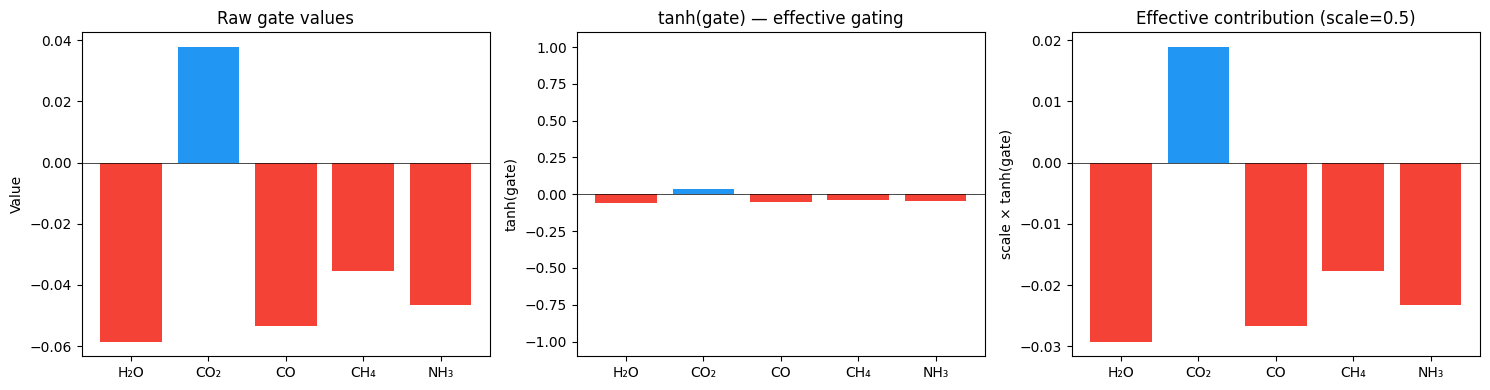

In [3]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

colors = ['#2196F3' if v >= 0 else '#F44336' for v in gate_tanh]

axes[0].bar(TARGET_NAMES, gate_raw, color=colors)
axes[0].set_title("Raw gate values")
axes[0].set_ylabel("Value")
axes[0].axhline(0, color="black", linewidth=0.5)

axes[1].bar(TARGET_NAMES, gate_tanh, color=colors)
axes[1].set_title("tanh(gate) — effective gating")
axes[1].set_ylabel("tanh(gate)")
axes[1].set_ylim(-1.1, 1.1)
axes[1].axhline(0, color="black", linewidth=0.5)

axes[2].bar(TARGET_NAMES, gate_effective, color=colors)
axes[2].set_title(f"Effective contribution (scale={QUANTUM_SCALE_AT_BEST})")
axes[2].set_ylabel(f"scale × tanh(gate)")
axes[2].axhline(0, color="black", linewidth=0.5)

plt.tight_layout()
plt.show()

In [4]:
# Interpretation
print("=== Gate Interpretation ===")
for i, name in enumerate(TARGET_NAMES):
    abs_gate = abs(gate_tanh[i])
    if abs_gate < 0.05:
        status = "SUPPRESSED — model ignores quantum"
    elif abs_gate < 0.3:
        status = "WEAK — minor quantum contribution"
    elif abs_gate < 0.7:
        status = "MODERATE — meaningful quantum contribution"
    else:
        status = "STRONG — significant quantum contribution"
    print(f"  {name}: |tanh(gate)| = {abs_gate:.4f} → {status}")

mean_abs = np.mean(np.abs(gate_tanh))
print(f"\nMean |tanh(gate)|: {mean_abs:.4f}")
if mean_abs < 0.1:
    print("VERDICT: Gate values near zero — quantum branch largely suppressed.")
else:
    print("VERDICT: Non-trivial gate values — model learned to use quantum branch.")

=== Gate Interpretation ===
  H₂O: |tanh(gate)| = 0.0585 → WEAK — minor quantum contribution
  CO₂: |tanh(gate)| = 0.0378 → SUPPRESSED — model ignores quantum
  CO: |tanh(gate)| = 0.0532 → WEAK — minor quantum contribution
  CH₄: |tanh(gate)| = 0.0355 → SUPPRESSED — model ignores quantum
  NH₃: |tanh(gate)| = 0.0465 → SUPPRESSED — model ignores quantum

Mean |tanh(gate)|: 0.0463
VERDICT: Gate values near zero — quantum branch largely suppressed.
